# RL with GC Subgoal Proposer

Train a simple goal-conditioned MLP policy with offline imitation learning on a `GCDataset`.

In [23]:
from __future__ import annotations

from typing import Any

import flax
import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from utils.datasets import GCDataset
from utils.flax_utils import TrainState, nonpytree_field
from utils.networks import ActorVectorField, MLP
from wrappers.datafuncs_utils import make_env_and_datasets


In [24]:
config = dict(
    env_name='humanoidmaze-medium-navigate-v0',
    # dataset_path='../../scratch/aorl2/YOUR_RUN_DIR/data-1000000.npz',
    dataset_path='../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz',
    observations_key='oracle_reps', # 'observations',
    goal_key='actor_goals',
    actions_key='low_actor_goals', #'actions',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    batch_size=256,
    num_train_steps=5000,
    log_interval=100,
    seed=0,
    value_p_curgoal=0.0,
    value_p_trajgoal=1.0,
    value_p_randomgoal=0.0,
    value_geom_sample=False,
    actor_p_curgoal=0.0,
    actor_p_trajgoal=1.0,
    actor_p_randomgoal=0.0,
    actor_geom_sample=True,
    gc_negative=False,
    subgoal_steps=25,
    discount=0.995
)

config

{'env_name': 'humanoidmaze-medium-navigate-v0',
 'dataset_path': '../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'actions_key': 'low_actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'batch_size': 256,
 'num_train_steps': 5000,
 'log_interval': 100,
 'seed': 0,
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'subgoal_steps': 25,
 'discount': 0.995}

In [ ]:
class GCMLPPolicy(nn.Module):
    hidden_dims: tuple[int, ...]
    action_dim: int
    layer_norm: bool = True

    @nn.compact
    def __call__(self, observations, goals):
        x = jnp.concatenate([observations, goals], axis=-1)
        x = MLP(self.hidden_dims, activate_final=True, layer_norm=self.layer_norm)(x)
        x = nn.Dense(self.action_dim)(x)
        return x


class GCILAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def actor_loss(self, batch, grad_params=None):
        observations = batch[self.config['observations_key']]
        goals = batch[self.config['goal_key']]
        pred_actions = self.network(observations, goals, params=grad_params)
        target_actions = batch[self.config['actions_key']]
        loss = jnp.mean(jnp.square(pred_actions - target_actions))
        mae = jnp.mean(jnp.abs(pred_actions - target_actions))
        return loss, {
            'loss': loss,
            'mae': mae,
        }

    @jax.jit
    def update(self, batch):
        new_rng, rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.actor_loss(batch, grad_params)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def sample_actions(self, observations, goals):
        return self.network(observations, goals)

    @classmethod
    def create(cls, example_batch, config):
        rng = jax.random.PRNGKey(config['seed'])
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = GCMLPPolicy(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        params = model.init(
            init_rng,
            example_batch[config['observations_key']],
            example_batch[config['goal_key']],
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))


In [26]:
env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=config['dataset_path'],
    use_oracle_reps=True,
)
train_dataset = GCDataset(base_train_dataset, config=config)

example_batch = train_dataset.sample(config['batch_size'])
print('env:', env.spec.id)
print('dataset keys:', sorted(base_train_dataset.keys()))
print('batch keys:', sorted(example_batch.keys()))
print(config['observations_key'] + ':', example_batch[config['observations_key']].shape)
print(config['goal_key'] + ':', example_batch[config['goal_key']].shape)
print(config['actions_key'] + ':', example_batch[config['actions_key']].shape)

env: humanoidmaze-medium-v0
dataset keys: ['actions', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals']
batch keys: ['actions', 'actor_goals', 'low_actor_goals', 'masks', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'rewards', 'terminals', 'value_goals']
oracle_reps: (256, 2)
actor_goals: (256, 2)
low_actor_goals: (256, 2)


In [35]:
from tqdm import tqdm

all_cells = {}

for ob in tqdm(train_dataset.dataset['observations']):
    key = (np.floor(ob[0]), np.floor(ob[1]))
    if key in all_cells:
        all_cells[key] += 1
    else:
        all_cells[key] = 1

all_cell_points = np.asarray(list(all_cells.keys()))

100%|██████████| 2000000/2000000 [00:05<00:00, 356469.72it/s]


In [27]:
agent = GCILAgent.create(example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, agent.network.params)

{'Dense_0': {'bias': (2,), 'kernel': (256, 2)},
 'MLP_0': {'Dense_0': {'bias': (256,), 'kernel': (4, 256)},
  'Dense_1': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_2': {'bias': (256,), 'kernel': (256, 256)},
  'LayerNorm_0': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_1': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_2': {'bias': (256,), 'scale': (256,)}}}

In [28]:
loss_history = []
mae_history = []

for step in range(1, config['num_train_steps'] + 1):
    batch = train_dataset.sample(config['batch_size'])
    agent, info = agent.update(batch)

    loss_history.append(float(info['loss']))
    mae_history.append(float(info['mae']))

    if step == 1 or step % config['log_interval'] == 0:
        print(
            f"step={step:05d} loss={loss_history[-1]:.6f} mae={mae_history[-1]:.6f}"
        )


step=00001 loss=134.853241 mae=9.949561
step=00100 loss=13.610046 mae=2.819453
step=00200 loss=4.529105 mae=1.591618
step=00300 loss=1.387558 mae=0.892558
step=00400 loss=0.879079 mae=0.744810
step=00500 loss=0.728149 mae=0.676887
step=00600 loss=0.745728 mae=0.666479
step=00700 loss=0.579765 mae=0.601137
step=00800 loss=0.792736 mae=0.690896
step=00900 loss=0.666374 mae=0.647707
step=01000 loss=0.648321 mae=0.647726
step=01100 loss=0.584013 mae=0.594612
step=01200 loss=0.625631 mae=0.613668
step=01300 loss=0.652816 mae=0.624154
step=01400 loss=0.596779 mae=0.614762
step=01500 loss=0.525957 mae=0.569445
step=01600 loss=0.762140 mae=0.695714
step=01700 loss=0.564107 mae=0.583210
step=01800 loss=0.566904 mae=0.574410
step=01900 loss=0.583402 mae=0.602456
step=02000 loss=0.580703 mae=0.591901
step=02100 loss=0.577662 mae=0.580076
step=02200 loss=0.574112 mae=0.609226
step=02300 loss=0.585579 mae=0.606984
step=02400 loss=0.560881 mae=0.589886
step=02500 loss=0.505484 mae=0.556472
step=0260

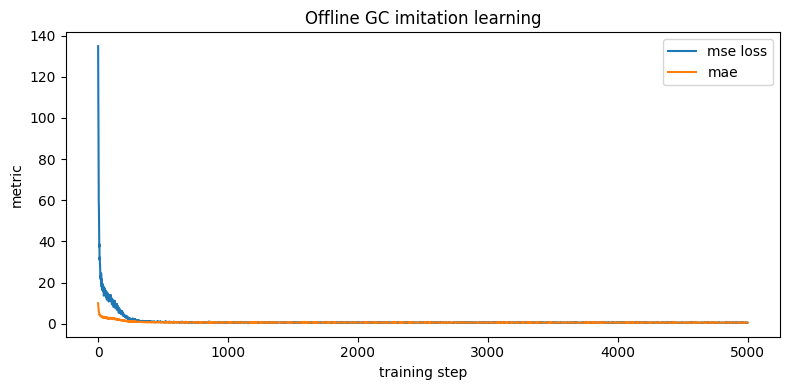

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label='mse loss')
plt.plot(mae_history, label='mae')
plt.xlabel('training step')
plt.ylabel('metric')
plt.title('Offline GC imitation learning')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
eval_batch = train_dataset.sample(8)
pred_actions = np.asarray(
    agent.sample_actions(
        eval_batch[config['observations_key']],
        eval_batch[config['goal_key']],
    )
)
target_actions = np.asarray(eval_batch[config['actions_key']])

print('predicted actions shape:', pred_actions.shape)
print('target actions shape:', target_actions.shape)
print('sample mse:', np.mean((pred_actions - target_actions) ** 2))

predicted actions shape: (8, 2)
target actions shape: (8, 2)
sample mse: 0.40139765


In [49]:
from tqdm import tqdm

replay_buffer = []

# ob = np.asarray([0.0, 0.0])
ob = np.asarray([15.0, 20.0])
goal = np.asarray([0.0, 18.0])
print(ob.shape)
print(goal)

for _ in tqdm(range(2000)):
    replay_buffer.append(ob)
    subgoal = agent.sample_actions(ob, goal)
    ob = subgoal

(2,)
[ 0. 18.]


100%|██████████| 2000/2000 [00:00<00:00, 3083.39it/s]


In [51]:
replay_buffer

array([[15.        , 20.        ],
       [15.30472279, 19.47418785],
       [15.73251915, 19.07228851],
       ...,
       [19.76557159, 14.542449  ],
       [19.7655735 , 14.542449  ],
       [19.76557159, 14.542449  ]])

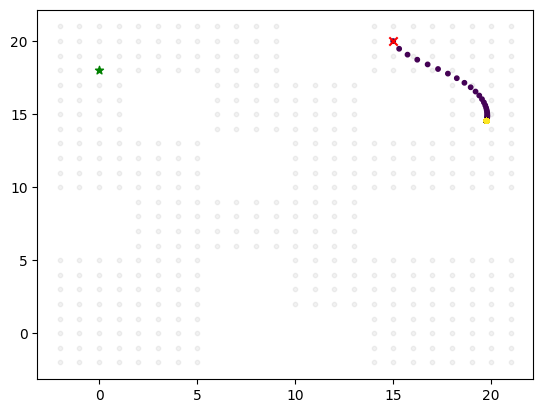

In [50]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')

Possible issue: if the subgoal agent is deterministic, there could be a fixed point.

(2,)
[ 5. 18.]


100%|██████████| 2000/2000 [00:00<00:00, 2530.62it/s]


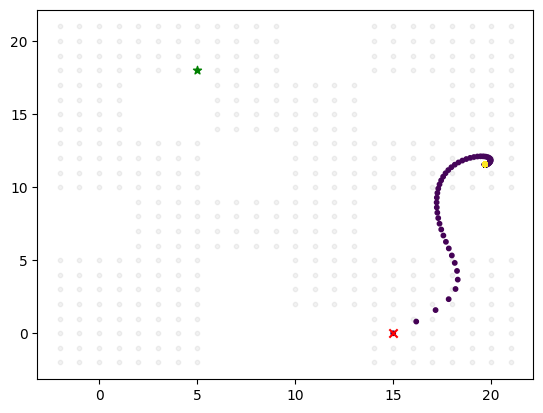

In [54]:
replay_buffer = []

# ob = np.asarray([0.0, 0.0])
ob = np.asarray([15.0, 0.0])
goal = np.asarray([5.0, 18.0])
print(ob.shape)
print(goal)

for _ in tqdm(range(2000)):
    replay_buffer.append(ob)
    subgoal = agent.sample_actions(ob, goal)
    ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')

## Using a Flow Network for the Proposer

In [56]:
config = dict(
    env_name='humanoidmaze-medium-navigate-v0',
    # dataset_path='../../scratch/aorl2/YOUR_RUN_DIR/data-1000000.npz',
    dataset_path='../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz',
    observations_key='oracle_reps', # 'observations',
    goal_key='actor_goals',
    actions_key='low_actor_goals', #'actions',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    batch_size=256,
    num_train_steps=5000,
    log_interval=100,
    seed=0,
    value_p_curgoal=0.0,
    value_p_trajgoal=1.0,
    value_p_randomgoal=0.0,
    value_geom_sample=False,
    actor_p_curgoal=0.0,
    actor_p_trajgoal=1.0,
    actor_p_randomgoal=0.0,
    actor_geom_sample=True,
    gc_negative=False,
    subgoal_steps=25,
    discount=0.995,
    flow_steps=10,
)

config

{'env_name': 'humanoidmaze-medium-navigate-v0',
 'dataset_path': '../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'actions_key': 'low_actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'batch_size': 256,
 'num_train_steps': 5000,
 'log_interval': 100,
 'seed': 0,
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'subgoal_steps': 25,
 'discount': 0.995,
 'flow_steps': 10}

In [59]:
from utils.networks import ActorVectorField

In [60]:
class GCFlowGoalProposerAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def flow_loss(self, batch, grad_params=None, rng=None):
        observations = batch[self.config['observations_key']]
        goals = batch[self.config['goal_key']]
        target_actions = batch[self.config['actions_key']]

        batch_size, action_dim = target_actions.shape
        rng = self.rng if rng is None else rng
        x_rng, t_rng = jax.random.split(rng)

        x_0 = jax.random.normal(x_rng, (batch_size, action_dim))
        t = jax.random.uniform(t_rng, (batch_size, 1))
        x_t = (1.0 - t) * x_0 + t * target_actions
        vel = target_actions - x_0

        pred_vel = self.network(
            observations,
            goals=goals,
            actions=x_t,
            times=t,
            params=grad_params,
        )
        loss = jnp.mean(jnp.square(pred_vel - vel))
        mae = jnp.mean(jnp.abs(pred_vel - vel))
        return loss, {
            'flow_loss': loss,
            'velocity_mae': mae,
        }

    @jax.jit
    def update(self, batch):
        new_rng, rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.flow_loss(batch, grad_params, rng=rng)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def sample_actions(self, observations, goals, rng):
        single_example = observations.ndim == 1
        if single_example:
            observations = observations[None, ...]
            goals = goals[None, ...]

        x = jax.random.normal(rng, (observations.shape[0], self.config['action_dim']))

        for i in range(self.config['flow_steps']):
            t = jnp.full((observations.shape[0], 1), i / self.config['flow_steps'])
            vels = self.network(observations, goals=goals, actions=x, times=t)
            x = x + vels / self.config['flow_steps']

        return x[0] if single_example else x

    @classmethod
    def create(cls, example_batch, config):
        rng = jax.random.PRNGKey(config['seed'])
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = ActorVectorField(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        params = model.init(
            init_rng,
            example_batch[config['observations_key']],
            goals=example_batch[config['goal_key']],
            actions=example_batch[config['actions_key']],
            times=example_batch[config['actions_key']][..., :1],
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        config = dict(config)
        config['action_dim'] = action_dim
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))

In [61]:
flow_agent = GCFlowGoalProposerAgent.create(example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, flow_agent.network.params)

{'mlp': {'Dense_0': {'bias': (256,), 'kernel': (7, 256)},
  'Dense_1': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_2': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_3': {'bias': (2,), 'kernel': (256, 2)},
  'LayerNorm_0': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_1': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_2': {'bias': (256,), 'scale': (256,)}}}

In [62]:
flow_loss_history = []
velocity_mae_history = []

for step in range(1, config['num_train_steps'] + 1):
    batch = train_dataset.sample(config['batch_size'])
    flow_agent, info = flow_agent.update(batch)

    flow_loss_history.append(float(info['flow_loss']))
    velocity_mae_history.append(float(info['velocity_mae']))

    if step == 1 or step % config['log_interval'] == 0:
        print(
            f"step={step:05d} flow_loss={flow_loss_history[-1]:.6f} velocity_mae={velocity_mae_history[-1]:.6f}"
        )


step=00001 flow_loss=152.453888 velocity_mae=10.672569
step=00100 flow_loss=11.851871 velocity_mae=2.632039
step=00200 flow_loss=5.128650 velocity_mae=1.746392
step=00300 flow_loss=3.301203 velocity_mae=1.448102
step=00400 flow_loss=2.231433 velocity_mae=1.179366
step=00500 flow_loss=1.813571 velocity_mae=1.059449
step=00600 flow_loss=1.746959 velocity_mae=1.023842
step=00700 flow_loss=1.626643 velocity_mae=1.009392
step=00800 flow_loss=1.565119 velocity_mae=1.003424
step=00900 flow_loss=1.905698 velocity_mae=1.090497
step=01000 flow_loss=1.764975 velocity_mae=1.050256
step=01100 flow_loss=1.556921 velocity_mae=1.005671
step=01200 flow_loss=1.594576 velocity_mae=0.995302
step=01300 flow_loss=1.554731 velocity_mae=0.953550
step=01400 flow_loss=1.524849 velocity_mae=0.973276
step=01500 flow_loss=1.355114 velocity_mae=0.936848
step=01600 flow_loss=1.523975 velocity_mae=0.962121
step=01700 flow_loss=1.454506 velocity_mae=0.951091
step=01800 flow_loss=1.607894 velocity_mae=0.982203
step=019

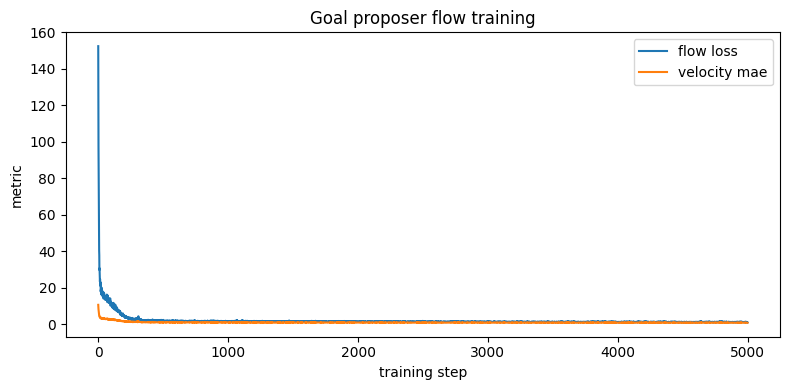

In [63]:
plt.figure(figsize=(8, 4))
plt.plot(flow_loss_history, label='flow loss')
plt.plot(velocity_mae_history, label='velocity mae')
plt.xlabel('training step')
plt.ylabel('metric')
plt.title('Goal proposer flow training')
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
eval_batch = train_dataset.sample(8)
rng = jax.random.PRNGKey(config['seed'])
rng, sample_rng = jax.random.split(rng)
pred_subgoals = np.asarray(
    flow_agent.sample_actions(
        eval_batch[config['observations_key']],
        eval_batch[config['goal_key']],
        sample_rng,
    )
)
target_subgoals = np.asarray(eval_batch[config['actions_key']])

print('predicted subgoals shape:', pred_subgoals.shape)
print('target subgoals shape:', target_subgoals.shape)
print('sample mse:', np.mean((pred_subgoals - target_subgoals) ** 2))

predicted subgoals shape: (8, 2)
target subgoals shape: (8, 2)
sample mse: 1.2193067


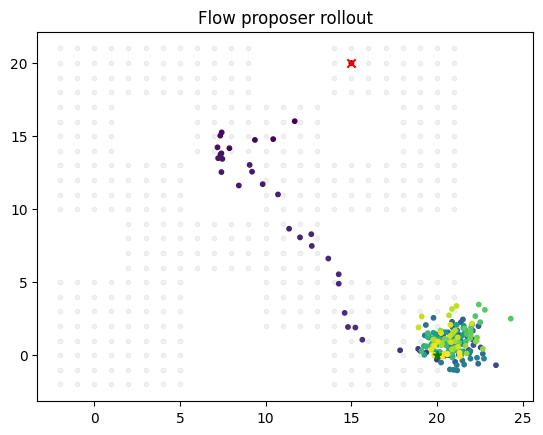

In [77]:
replay_buffer = []
ob = np.asarray([15.0, 20.0])
goal = np.asarray([20.0, 0.0])
rng = jax.random.PRNGKey(config['seed'])

for s in range(200):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

It cheats — doesn't actually obey reachability constraints.

## Get GCFQL Agent Checkpoint

In [78]:
AGENT_CHECKPOINT = '../../scratch/aorl2/2026-03-16-00/2026-03-16-00.0dfb77fdff1e9bb91c8f7575c8ad2c3f7d867f93572cfb2780acc46d86598233/'
CKPT_NUM = 1000000

In [80]:
import glob
import json
from pathlib import Path

from agents import agents
from utils.datasets import GCDataset, HGCDataset
from utils.flax_utils import restore_agent

In [ ]:
checkpoint_dir = Path(AGENT_CHECKPOINT).expanduser()
with open(checkpoint_dir / 'flags.json', 'r') as f:
    saved_flags = json.load(f)

dataset_path = checkpoint_dir / f'data-{CKPT_NUM}.npz'
if not dataset_path.exists():
    dataset_dir = saved_flags.get('dataset_dir')
    if dataset_dir is None:
        raise FileNotFoundError(f'Could not find {dataset_path} and no dataset_dir in flags.json')
    dataset_candidates = [
        file for file in sorted(glob.glob(f"{dataset_dir}/*.npz")) if '-val.npz' not in file
    ]
    if not dataset_candidates:
        raise FileNotFoundError(f'No dataset files found in {dataset_dir}')
    dataset_path = Path(dataset_candidates[0])

gcfql_config = saved_flags['agent']
seed = saved_flags.get('seed', 0)
env_name = saved_flags['env_name']

env, base_train_dataset, _ = make_env_and_datasets(
    env_name,
    dataset_path=str(dataset_path),
    use_oracle_reps=True,
)
dataset_class = {
    'GCDataset': GCDataset,
    'HGCDataset': HGCDataset,
}[gcfql_config['dataset_class']]
restored_train_dataset = dataset_class(base_train_dataset, gcfql_config)
example_batch = restored_train_dataset.sample(1)

gcfql_agent = agents[gcfql_config['agent_name']].create(seed, example_batch, gcfql_config)
gcfql_agent = restore_agent(gcfql_agent, str(checkpoint_dir), CKPT_NUM)



Restored from ../../scratch/aorl2/2026-03-16-00/2026-03-16-00.0dfb77fdff1e9bb91c8f7575c8ad2c3f7d867f93572cfb2780acc46d86598233/params_1000000.pkl
restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 25
total reward: -25.0
last info: {'xy': array([15.01225893, 19.03727086]), 'prev_qpos': array([15.05870008, 19.06397388,  0.46233323,  0.31794646,  0.02732717,
        0.42402196,  0.84756631,  0.32407666,  0.52020897, -0.62040153,
       -0.4442826 , -1.07984134, -1.57923752,  0.04429267,  0.19302407,
        1.01057706, -0.38806025, -0.75228104, -1.3309804 , -2.80127898,
       -0.95328475,  0.88178869, -0.92625851, -1.32903351, -0.46865593,
       -1.07417967, -0.75883828,  0.88250168]), 'prev_qvel': array([-1.95204347e+00, -9.12899820e-01,  1.30229646e+00, -7.03014004e+00,
       -4.69560567e-01, -3.43708471e+00,  2.90772267e+00,  1.72981301e+00,

In [89]:
rollout_steps = 250
task_id = 1
rng = jax.random.PRNGKey(seed)
observation, info = env.reset(options=dict(task_id=task_id))
goal = info.get('goal')
if goal is None:
    raise ValueError('Environment reset did not return a goal.')
if 'oracle_reps' in example_batch:
    goal = goal[: example_batch['oracle_reps'].shape[-1]]

traj_obs = [np.asarray(observation)]
traj_actions = []
traj_rewards = []

for step in tqdm(range(rollout_steps)):
    rng, action_rng = jax.random.split(rng)
    action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=goal, seed=action_rng))
    next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))
    traj_actions.append(action)
    traj_rewards.append(reward)
    traj_obs.append(np.asarray(next_observation))
    observation = next_observation
    if terminated or truncated:
        print(f'rollout ended at step {step + 1}')
        break

traj_obs = np.asarray(traj_obs)
traj_actions = np.asarray(traj_actions)
traj_rewards = np.asarray(traj_rewards)

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('total reward:', float(traj_rewards.sum()) if len(traj_rewards) else 0.0)
print('last info:', info)

100%|██████████| 250/250 [00:00<00:00, 320.88it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
total reward: -250.0
last info: {'xy': array([17.58177146, 21.70472201]), 'prev_qpos': array([17.5762145 , 21.70827353,  0.36370339, -0.28513899, -0.33633536,
       -0.46122764, -0.76996321,  0.31906293,  0.44287735, -0.13750961,
       -0.44378149, -0.1405818 , -1.92861844,  0.04406815,  0.71939573,
       -0.68021527, -0.44425978,  0.08323169, -0.76093746, -1.67949815,
       -0.81416581,  0.58477914,  0.40478456,  0.78465556,  0.52007815,
       -0.9058202 , -0.1889211 , -1.57860476]), 'prev_qvel': array([ 0.24393478, -0.10978628, -0.19007889,  1.00369802,  0.84011355,
        0.12796741, -0.80751347,  0.43049087, -2.10204711,  0.02276044,
       -1.87496089,  0.42578491,  0.07750689, -7.53976275,  9.72785301,
       -0.3294363 , -2.17218485, -4.92663186, -0.47053588,  3.7042611 ,
     

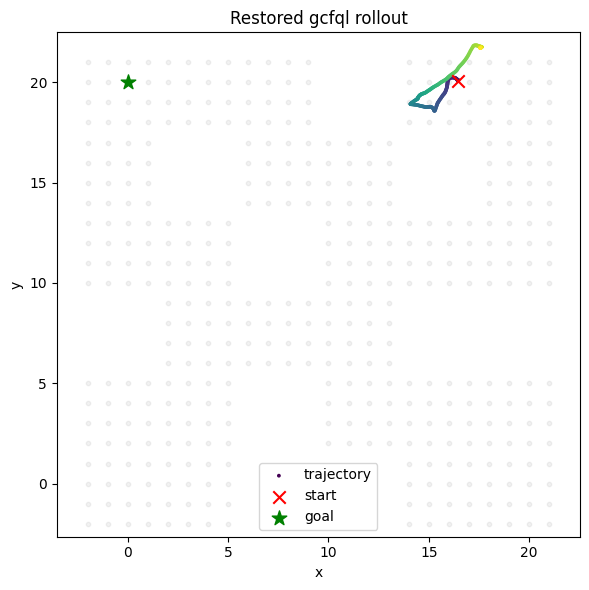

In [90]:
if traj_obs.shape[-1] >= 2:
    plt.figure(figsize=(6, 6))
    plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
    plt.scatter(traj_obs[:, 0], traj_obs[:, 1], marker='o', s=3, label='trajectory', cmap='viridis', c=np.arange(len(traj_obs)))
    plt.scatter(traj_obs[0, 0], traj_obs[0, 1], c='red', marker='x', s=80, label='start')
    plt.scatter(goal[0], goal[1], c='green', marker='*', s=120, label='goal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Restored gcfql rollout')
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print('Observation does not have at least 2 dims to plot.')

## Checking subgoals

In [92]:
from wrappers.datafuncs_utils import to_oracle_reps

In [111]:
rollout_steps = 250
task_id = 1
rng = jax.random.PRNGKey(seed)
observation, info = env.reset(options=dict(task_id=task_id))
goal = info.get('goal')
if goal is None:
    raise ValueError('Environment reset did not return a goal.')
if 'oracle_reps' in example_batch:
    goal = goal[: example_batch['oracle_reps'].shape[-1]]

traj_obs = [np.asarray(observation)]
traj_actions = []
traj_rewards = []
proposed_subgoals = []

for step in tqdm(range(rollout_steps)):
    rng, action_rng = jax.random.split(rng)
    action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=goal, seed=action_rng))

    rng, sample_rng = jax.random.split(rng)
    subgoal = flow_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None], sample_rng)[0]

    next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))
    traj_actions.append(action)
    traj_rewards.append(reward)
    traj_obs.append(np.asarray(next_observation))
    proposed_subgoals.append(subgoal)
    observation = next_observation
    if terminated or truncated:
        print(f'rollout ended at step {step + 1}')
        break

traj_obs = np.asarray(traj_obs)
traj_actions = np.asarray(traj_actions)
traj_rewards = np.asarray(traj_rewards)
proposed_subgoals = np.asarray(proposed_subgoals)

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('total reward:', float(traj_rewards.sum()) if len(traj_rewards) else 0.0)
print('last info:', info)

100%|██████████| 250/250 [00:01<00:00, 139.50it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
total reward: -250.0
last info: {'xy': array([14.62902179, 19.48482942]), 'prev_qpos': array([ 1.46272191e+01,  1.94836892e+01,  3.57605320e-01,  1.21662257e-01,
       -1.92387470e-02, -4.90400887e-01, -8.62748594e-01,  1.92209468e-01,
       -3.34046335e-01, -1.65575367e-01, -4.44175631e-01,  1.10741223e-01,
       -1.92638903e+00,  4.43973991e-02, -8.81921981e-01, -8.80129740e-01,
       -4.42504369e-01, -3.57143281e-01,  3.53172337e-01, -2.76602893e+00,
       -8.82137086e-01,  8.82028064e-01, -1.49097495e+00, -1.49028695e+00,
        1.62499034e-01, -1.03594932e+00,  4.26028439e-02,  8.67603812e-01]), 'prev_qvel': array([ 3.79572002e-02,  5.26440441e-02, -1.13765227e-02,  2.16993066e-01,
       -2.29665604e-01, -1.42275515e-01,  4.33256336e-01,  4.17084635e-01,
       -3.78220786e-01, 

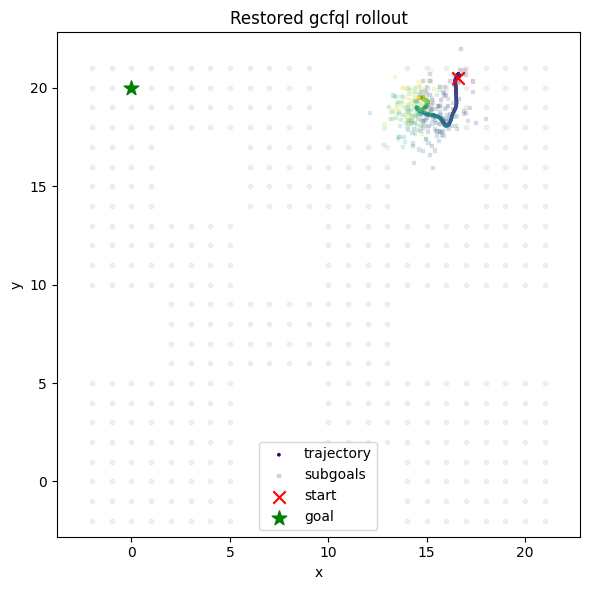

In [112]:
if traj_obs.shape[-1] >= 2:
    plt.figure(figsize=(6, 6))
    plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
    plt.scatter(traj_obs[:, 0], traj_obs[:, 1], marker='o', s=3, label='trajectory', cmap='viridis', c=np.arange(len(traj_obs)))
    plt.scatter(proposed_subgoals[:, 0], proposed_subgoals[:, 1], marker='s', alpha=0.15, s=5, label='subgoals', cmap='viridis', c=np.arange(len(proposed_subgoals)))
    plt.scatter(traj_obs[0, 0], traj_obs[0, 1], c='red', marker='x', s=80, label='start')
    plt.scatter(goal[0], goal[1], c='green', marker='*', s=120, label='goal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Restored gcfql rollout')
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print('Observation does not have at least 2 dims to plot.')

In [125]:
rollout_steps = 250
task_id = 1
rng = jax.random.PRNGKey(seed)
observation, info = env.reset(options=dict(task_id=task_id))
goal = info.get('goal')
if goal is None:
    raise ValueError('Environment reset did not return a goal.')
if 'oracle_reps' in example_batch:
    goal = goal[: example_batch['oracle_reps'].shape[-1]]

traj_obs = [np.asarray(observation)]
traj_actions = []
traj_rewards = []
proposed_subgoals = []

for step in tqdm(range(rollout_steps)):
    rng, sample_rng = jax.random.split(rng)
    subgoal = flow_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None], sample_rng)[0]

    rng, action_rng = jax.random.split(rng)
    action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=subgoal, seed=action_rng))

    next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))
    traj_actions.append(action)
    traj_rewards.append(reward)
    traj_obs.append(np.asarray(next_observation))
    proposed_subgoals.append(subgoal)
    observation = next_observation
    if terminated or truncated:
        print(f'rollout ended at step {step + 1}')
        break

traj_obs = np.asarray(traj_obs)
traj_actions = np.asarray(traj_actions)
traj_rewards = np.asarray(traj_rewards)
proposed_subgoals = np.asarray(proposed_subgoals)

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('total reward:', float(traj_rewards.sum()) if len(traj_rewards) else 0.0)
print('last info:', info)

  0%|          | 0/250 [00:00<?, ?it/s]

100%|██████████| 250/250 [00:01<00:00, 137.77it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
total reward: -250.0
last info: {'xy': array([16.92050353, 19.0893971 ]), 'prev_qpos': array([ 1.68542690e+01,  1.90625222e+01,  1.20934154e+00,  2.85492962e-01,
       -1.08773075e-02, -1.05511165e-01,  9.52492964e-01,  5.21989338e-01,
       -4.01132315e-01,  1.42872565e-01,  1.67297042e-01, -9.98087055e-01,
        3.18911707e-01,  1.90969122e-01, -9.67025388e-02, -4.93880423e-01,
        1.00358401e-01, -8.45490842e-01, -3.96835101e-01,  5.53015693e-02,
        1.74182755e-01, -4.86955569e-01,  8.97221533e-01, -2.34777282e-01,
        9.08954233e-01, -1.07980342e+00, -8.02012682e-01,  9.05035634e-01]), 'prev_qvel': array([ 2.60032849,  1.09834995, -0.13277735, -1.00050214,  1.11390427,
       -6.86466937,  3.62925756, -1.39420139,  5.7273778 , -0.35664004,
       -0.37364265, -4.665132 

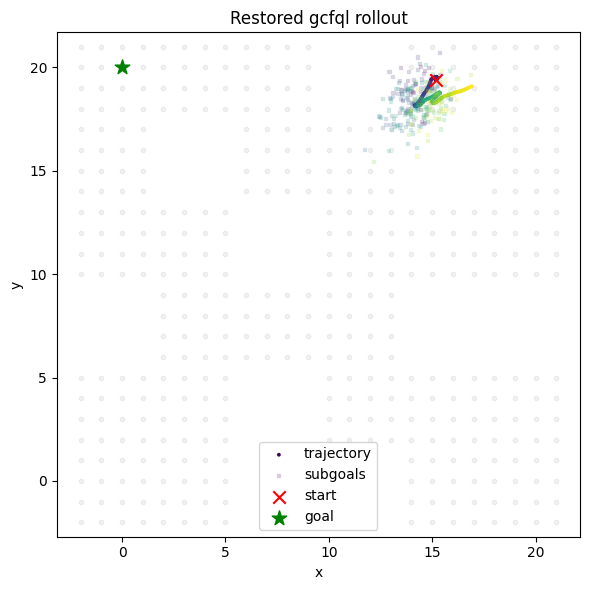

In [126]:
if traj_obs.shape[-1] >= 2:
    plt.figure(figsize=(6, 6))
    plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
    plt.scatter(traj_obs[:, 0], traj_obs[:, 1], marker='o', s=3, label='trajectory', cmap='viridis', c=np.arange(len(traj_obs)))
    plt.scatter(proposed_subgoals[:, 0], proposed_subgoals[:, 1], marker='s', alpha=0.15, s=5, label='subgoals', cmap='viridis', c=np.arange(len(proposed_subgoals)))
    plt.scatter(traj_obs[0, 0], traj_obs[0, 1], c='red', marker='x', s=80, label='start')
    plt.scatter(goal[0], goal[1], c='green', marker='*', s=120, label='goal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Restored gcfql rollout')
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print('Observation does not have at least 2 dims to plot.')

## What is more likely to make it out of the bottleneck?

In [140]:
rollout_steps = 250
task_id = 1

goal_y = 15.0
num_trials = 20
num_successes = 0

rng = jax.random.PRNGKey(seed)

for trial in tqdm(range(num_trials)):
    rng, _ = jax.random.split(rng)
    observation, info = env.reset(options=dict(task_id=task_id))
    goal = info.get('goal')
    if goal is None:
        raise ValueError('Environment reset did not return a goal.')
    if 'oracle_reps' in example_batch:
        goal = goal[: example_batch['oracle_reps'].shape[-1]]

    for step in tqdm(range(rollout_steps)):
        rng, action_rng = jax.random.split(rng)
        action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=goal, seed=action_rng))

        next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))

        observation = next_observation
        # if terminated or truncated:
        #     print(f'rollout ended at step {step + 1}')
        #     break

        if observation[1] < goal_y:
            num_successes += 1
            break

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('num_breakouts:', num_successes)
print('breakout_rate:', num_successes / num_trials)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:17<00:00,  1.12it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
num_breakouts: 0
breakout_rate: 0.0


In [141]:
rollout_steps = 250
task_id = 1

goal_y = 15.0
num_trials = 20
num_successes = 0
subgoal = None

rng = jax.random.PRNGKey(seed)

for trial in tqdm(range(num_trials)):
    rng, _ = jax.random.split(rng)
    observation, info = env.reset(options=dict(task_id=task_id))
    goal = info.get('goal')
    if goal is None:
        raise ValueError('Environment reset did not return a goal.')
    if 'oracle_reps' in example_batch:
        goal = goal[: example_batch['oracle_reps'].shape[-1]]
        
    for step in tqdm(range(rollout_steps)):
        if subgoal is None or np.linalg.norm(subgoal - observation[:2]) < 0.05:
            rng, sample_rng = jax.random.split(rng)
            subgoal = flow_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None], sample_rng)[0]

        rng, action_rng = jax.random.split(rng)
        action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=subgoal, seed=action_rng))

        next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))

        observation = next_observation
        # if terminated or truncated:
        #     print(f'rollout ended at step {step + 1}')
        #     break

        if observation[1] < goal_y:
            num_successes += 1
            break

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('num_breakouts:', num_successes)
print('breakout_rate:', num_successes / num_trials)

100%|██████████| 20/20 [00:18<00:00,  1.06it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
num_breakouts: 3
breakout_rate: 0.15


In [158]:
rollout_steps = 250
subgoal_rollout_steps = 25
task_id = 1
rng = jax.random.PRNGKey(seed)
observation, info = env.reset(options=dict(task_id=task_id))
goal = info.get('goal')
if goal is None:
    raise ValueError('Environment reset did not return a goal.')
if 'oracle_reps' in example_batch:
    goal = goal[: example_batch['oracle_reps'].shape[-1]]

traj_obs = [np.asarray(observation)]
traj_actions = []
traj_rewards = []
proposed_subgoals = []
subgoal = None

for step in tqdm(range(rollout_steps)):
    if subgoal is None or np.linalg.norm(subgoal - observation[:2]) < 0.05 or subgoal_steps == subgoal_rollout_steps:
        subgoal_steps = 0
        rng, sample_rng = jax.random.split(rng)
        subgoal = flow_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None], sample_rng)[0]

    rng, action_rng = jax.random.split(rng)
    action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=subgoal, seed=action_rng))
    subgoal_steps += 1

    next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))
    traj_actions.append(action)
    traj_rewards.append(reward)
    traj_obs.append(np.asarray(next_observation))
    proposed_subgoals.append(subgoal)
    observation = next_observation
    if terminated or truncated:
        print(f'rollout ended at step {step + 1}')
        break

traj_obs = np.asarray(traj_obs)
traj_actions = np.asarray(traj_actions)
traj_rewards = np.asarray(traj_rewards)
proposed_subgoals = np.asarray(proposed_subgoals)

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('total reward:', float(traj_rewards.sum()) if len(traj_rewards) else 0.0)
print('last info:', info)

  0%|          | 0/250 [00:00<?, ?it/s]

100%|██████████| 250/250 [00:00<00:00, 251.25it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
total reward: -250.0
last info: {'xy': array([16.86474356, 18.23827288]), 'prev_qpos': array([16.85599905, 18.22663276,  1.07686199,  0.07003952, -0.08698617,
       -0.11458368,  0.98711623,  0.06791655, -0.68323392, -0.36513069,
        0.12490109, -0.89977131,  0.43537198, -1.84657888, -0.88063111,
       -0.88142185, -0.19246589, -0.92373011, -0.30893978,  0.32286823,
        0.5033121 , -0.99009217,  0.93398691, -1.30649393,  0.71720843,
       -1.05401981, -0.09796753,  0.6935696 ]), 'prev_qvel': array([ 3.52377988e-01,  4.22543373e-01,  2.98369275e-01,  2.03899288e+00,
        6.48411484e-01,  2.06637406e+00, -6.38668246e+00,  2.32576283e+00,
        3.81487103e+00,  7.17339889e+00,  2.52645815e+00, -2.18190999e+00,
        9.16043966e+00,  7.43943463e-03,  1.50886175e-01,  4.4692919

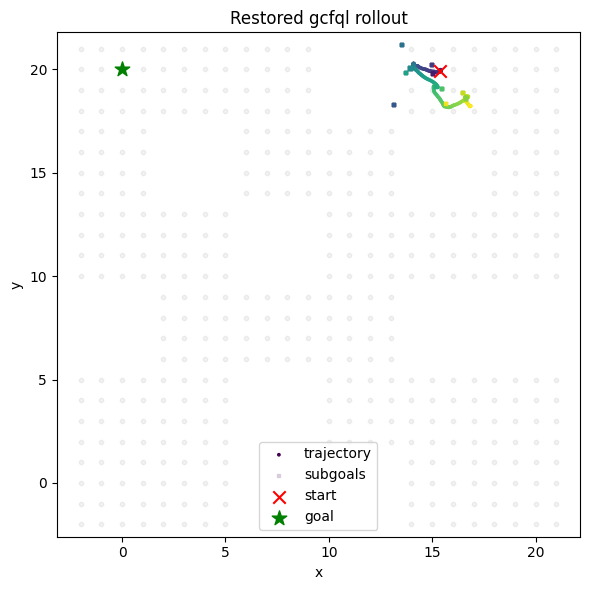

In [159]:
if traj_obs.shape[-1] >= 2:
    plt.figure(figsize=(6, 6))
    plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
    plt.scatter(traj_obs[:, 0], traj_obs[:, 1], marker='o', s=3, label='trajectory', cmap='viridis', c=np.arange(len(traj_obs)))
    plt.scatter(proposed_subgoals[:, 0], proposed_subgoals[:, 1], marker='s', alpha=0.15, s=5, label='subgoals', cmap='viridis', c=np.arange(len(proposed_subgoals)))
    plt.scatter(traj_obs[0, 0], traj_obs[0, 1], c='red', marker='x', s=80, label='start')
    plt.scatter(goal[0], goal[1], c='green', marker='*', s=120, label='goal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Restored gcfql rollout')
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print('Observation does not have at least 2 dims to plot.')

In [160]:
rollout_steps = 250
subgoal_rollout_steps = 25
task_id = 1

goal_y = 15.0
num_trials = 20
num_successes = 0
subgoal = None

rng = jax.random.PRNGKey(seed)

for trial in tqdm(range(num_trials)):
    rng, _ = jax.random.split(rng)
    observation, info = env.reset(options=dict(task_id=task_id))
    goal = info.get('goal')
    if goal is None:
        raise ValueError('Environment reset did not return a goal.')
    if 'oracle_reps' in example_batch:
        goal = goal[: example_batch['oracle_reps'].shape[-1]]
        
    for step in tqdm(range(rollout_steps)):
        if subgoal is None or np.linalg.norm(subgoal - observation[:2]) < 0.05 or subgoal_steps == subgoal_rollout_steps:
            subgoal_steps = 0
            rng, sample_rng = jax.random.split(rng)
            subgoal = flow_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None], sample_rng)[0]

        rng, action_rng = jax.random.split(rng)
        action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=subgoal, seed=action_rng))
        subgoal_steps += 1

        next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))

        observation = next_observation
        # if terminated or truncated:
        #     print(f'rollout ended at step {step + 1}')
        #     break

        if observation[1] < goal_y:
            num_successes += 1
            break

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('num_breakouts:', num_successes)
print('breakout_rate:', num_successes / num_trials)

100%|██████████| 20/20 [00:19<00:00,  1.01it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
num_breakouts: 1
breakout_rate: 0.05


In [199]:
rollout_steps = 250
subgoal_rollout_steps = 25
task_id = 1

goal_y = 15.0
num_trials = 20
num_successes = 0
subgoal = None

rng = jax.random.PRNGKey(seed)

for trial in tqdm(range(num_trials)):
    rng, _ = jax.random.split(rng)
    observation, info = env.reset(options=dict(task_id=task_id))
    goal = info.get('goal')
    if goal is None:
        raise ValueError('Environment reset did not return a goal.')
    if 'oracle_reps' in example_batch:
        goal = goal[: example_batch['oracle_reps'].shape[-1]]
        
    for step in tqdm(range(rollout_steps)):
        if subgoal is None or np.linalg.norm(subgoal - observation[:2]) < 0.05 or subgoal_steps == subgoal_rollout_steps:
            subgoal_steps = 0
            rng, sample_rng = jax.random.split(rng)
            subgoal = agent.sample_actions(to_oracle_reps(observation[None], env), goal[None])[0]

        rng, action_rng = jax.random.split(rng)
        action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=subgoal, seed=action_rng))
        subgoal_steps += 1

        next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))

        observation = next_observation
        # if terminated or truncated:
        #     print(f'rollout ended at step {step + 1}')
        #     break

        if observation[1] < goal_y:
            num_successes += 1
            break

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('num_breakouts:', num_successes)
print('breakout_rate:', num_successes / num_trials)

100%|██████████| 20/20 [00:23<00:00,  1.19s/it]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
num_breakouts: 0
breakout_rate: 0.0


## Learn the Differences Instead of the Subgoals Themselves

In [184]:
delta_config = dict(config)
delta_config.update(
    observations_key='oracle_reps',
    goal_key='actor_goals',
    actions_key='low_actor_goals',
    hidden_dims=(256, 256, 256), # (64, 64),
    lr=3e-4,
    batch_size=256,
    num_train_steps=5000,
    log_interval=100,
)

class GCDeltaAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def delta_loss(self, batch, grad_params=None):
        observations = batch[self.config['observations_key']]
        goals = batch[self.config['goal_key']]
        target_actions = batch[self.config['actions_key']]
        target_deltas = target_actions - observations

        pred_deltas = self.network(observations, goals, params=grad_params)
        pred_actions = observations + pred_deltas

        delta_loss = jnp.mean(jnp.square(pred_deltas - target_deltas))
        action_mse = jnp.mean(jnp.square(pred_actions - target_actions))
        action_mae = jnp.mean(jnp.abs(pred_actions - target_actions))
        return delta_loss, {
            'delta_loss': delta_loss,
            'action_mse': action_mse,
            'action_mae': action_mae,
        }

    @jax.jit
    def update(self, batch):
        new_rng, _ = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.delta_loss(batch, grad_params)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def sample_actions(self, observations, goals):
        single_example = observations.ndim == 1
        if single_example:
            observations = observations[None, ...]
            goals = goals[None, ...]

        pred_deltas = self.network(observations, goals)
        pred_actions = observations + pred_deltas
        return pred_actions[0] if single_example else pred_actions

    @classmethod
    def create(cls, example_batch, config):
        rng = jax.random.PRNGKey(config['seed'])
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = GCMLPPolicy(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        params = model.init(
            init_rng,
            example_batch[config['observations_key']],
            example_batch[config['goal_key']],
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))

In [185]:
delta_agent = GCDeltaAgent.create(example_batch, delta_config)
delta_loss_history = []
delta_action_mse_history = []
delta_action_mae_history = []

for step in range(1, delta_config['num_train_steps'] + 1):
    batch = train_dataset.sample(delta_config['batch_size'])
    delta_agent, info = delta_agent.update(batch)

    delta_loss_history.append(float(info['delta_loss']))
    delta_action_mse_history.append(float(info['action_mse']))
    delta_action_mae_history.append(float(info['action_mae']))

    if step == 1 or step % delta_config['log_interval'] == 0:
        print(
            f"step={step:05d} delta_loss={delta_loss_history[-1]:.6f} "
            f"action_mse={delta_action_mse_history[-1]:.6f} "
            f"action_mae={delta_action_mae_history[-1]:.6f}"
        )

eval_batch = train_dataset.sample(8)
pred_actions = np.asarray(
    delta_agent.sample_actions(
        eval_batch[delta_config['observations_key']],
        eval_batch[delta_config['goal_key']],
    )
)
target_actions = np.asarray(eval_batch[delta_config['actions_key']])

print('delta model sample mse:', np.mean((pred_actions - target_actions) ** 2))

step=00001 delta_loss=1.427860 action_mse=1.427860 action_mae=0.943046
step=00100 delta_loss=0.564477 action_mse=0.564477 action_mae=0.598236
step=00200 delta_loss=0.537378 action_mse=0.537378 action_mae=0.549592
step=00300 delta_loss=0.514630 action_mse=0.514630 action_mae=0.557089
step=00400 delta_loss=0.521735 action_mse=0.521735 action_mae=0.556315
step=00500 delta_loss=0.439069 action_mse=0.439069 action_mae=0.499367
step=00600 delta_loss=0.524846 action_mse=0.524846 action_mae=0.553599
step=00700 delta_loss=0.494896 action_mse=0.494896 action_mae=0.539337
step=00800 delta_loss=0.485576 action_mse=0.485576 action_mae=0.536894
step=00900 delta_loss=0.490052 action_mse=0.490052 action_mae=0.537738
step=01000 delta_loss=0.460497 action_mse=0.460497 action_mae=0.529001
step=01100 delta_loss=0.460128 action_mse=0.460128 action_mae=0.511931
step=01200 delta_loss=0.455766 action_mse=0.455766 action_mae=0.535864
step=01300 delta_loss=0.483931 action_mse=0.483931 action_mae=0.519585
step=0

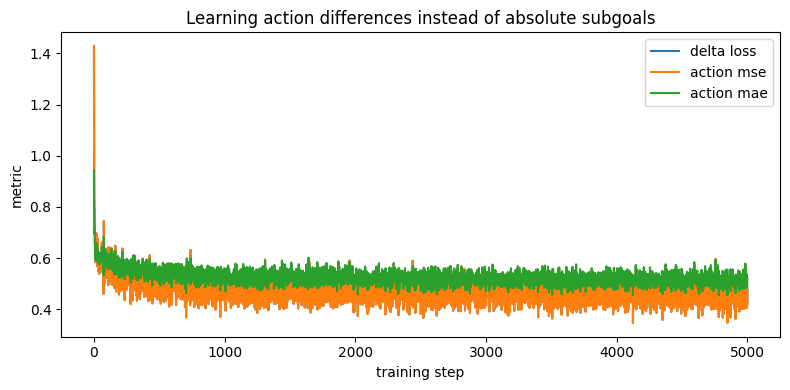

In [186]:
plt.figure(figsize=(8, 4))
plt.plot(delta_loss_history, label='delta loss')
plt.plot(delta_action_mse_history, label='action mse')
plt.plot(delta_action_mae_history, label='action mae')
plt.xlabel('training step')
plt.ylabel('metric')
plt.title('Learning action differences instead of absolute subgoals')
plt.legend()
plt.tight_layout()
plt.show()

In [193]:
replay_buffer = []
ob = np.asarray([15.0, 12.0])
goal = np.asarray([0.0, 0.0])
rng = jax.random.PRNGKey(delta_config['seed'])

for s in range(200):
    replay_buffer.append(ob.copy())
    pred_delta = np.asarray(
        delta_agent.network(
            ob[None, ...],
            goal[None, ...],
        )[0]
    )
    subgoal = ob + pred_delta
    # print('delta:', pred_delta, 'subgoal:', subgoal)

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached fixed point at step {s}')
        break

    ob = subgoal

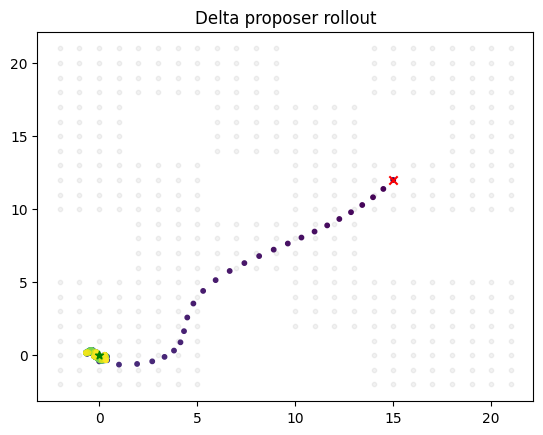

In [194]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Delta proposer rollout')
plt.show()

In [203]:
replay_buffer = []
ob = np.asarray([15.0, 12.0])
goal = np.asarray([0.0, 0.0])
rng = jax.random.PRNGKey(delta_config['seed'])

for s in range(200):
    replay_buffer.append(ob.copy())
    pred_delta = np.asarray(
        agent.network(
            ob[None, ...],
            goal[None, ...],
        )[0]
    )
    subgoal = pred_delta
    # print('delta:', pred_delta, 'subgoal:', subgoal)

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached fixed point at step {s}')
        break

    ob = subgoal

reached fixed point at step 27


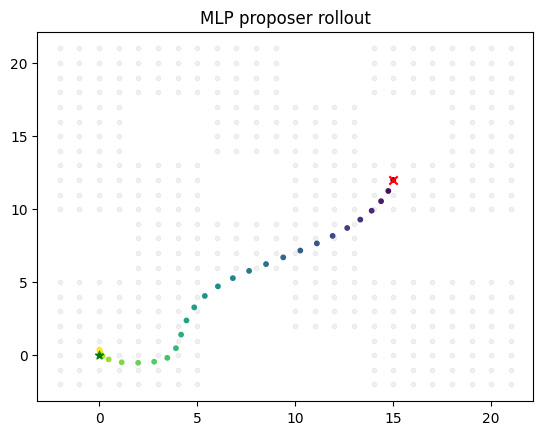

In [204]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('MLP proposer rollout')
plt.show()

All else being equal, learning the difference doesn't matter.

reached at step 121!
subgoal: [-0.04358669 -0.1450014 ]


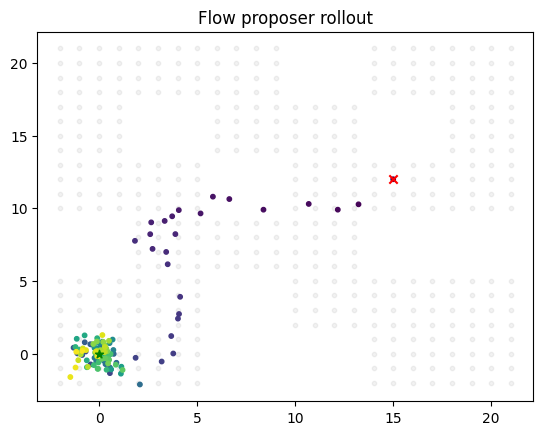

In [201]:
replay_buffer = []
ob = np.asarray([15.0, 12.0])
goal = np.asarray([0.0, 0.0])
rng = jax.random.PRNGKey(config['seed'])

for s in range(200):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

In [244]:
replay_buffer = []
ob = np.asarray([14.5, 20.0])
goal = np.asarray([11.0, 8.0])
rng = jax.random.PRNGKey(delta_config['seed'])

for s in range(200):
    replay_buffer.append(ob.copy())

    subgoal = np.asarray(
        agent.network(
            ob[None, ...],
            goal[None, ...],
        )[0]
    )

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached fixed point at step {s}')
        rng, subkey = jax.random.split(rng)
        noise = np.asarray(jax.random.normal(subkey, shape=ob.shape)) * 0.1
        ob = ob + noise
        print(f'adding: {noise}')
    else:
        ob = subgoal

reached fixed point at step 36
adding: [-0.24424557 -0.20356806]
reached fixed point at step 37
adding: [-0.12574776 -0.04016044]
reached fixed point at step 38
adding: [-0.13877682  0.07748543]
reached fixed point at step 39
adding: [-0.23022664  0.0052778 ]
reached fixed point at step 40
adding: [-0.10147804  0.15873006]
reached fixed point at step 43
adding: [-0.01981789  0.07955903]
reached fixed point at step 46
adding: [-0.03021937 -0.1139671 ]
reached fixed point at step 47
adding: [-0.07427701  0.09748424]
reached fixed point at step 48
adding: [-0.0200383  -0.01144468]
reached fixed point at step 49
adding: [-0.03177674  0.00737342]
reached fixed point at step 50
adding: [-0.08475428  0.0507578 ]
reached fixed point at step 52
adding: [-0.02507795 -0.07602494]
reached fixed point at step 53
adding: [0.1830863  0.04328811]
reached fixed point at step 54
adding: [-0.15585093 -0.0787986 ]
reached fixed point at step 55
adding: [0.13490531 0.04142695]
reached fixed point at step 5

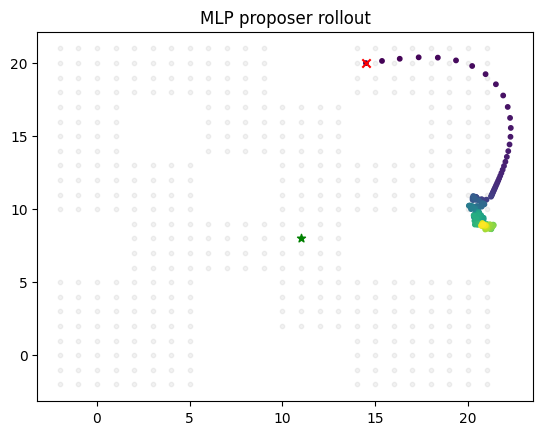

In [245]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('MLP proposer rollout')
plt.show()

reached at step 176!
subgoal: [11.147488 10.305457]


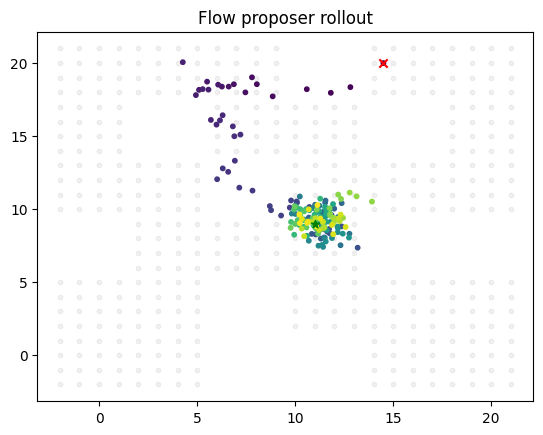

In [243]:
replay_buffer = []
ob = np.asarray([14.5, 20.0])
goal = np.asarray([11.0, 9.0])
rng = jax.random.PRNGKey(config['seed'])

for s in range(200):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

## REINFORCE Stage

In [ ]:
from wrappers.datafuncs_utils import to_oracle_reps

reinforce_config = dict(
    lr=1e-4,
    seed=0,
    num_updates=200,
    episodes_per_update=16,
    controller_horizon=25,
    reach_threshold=0.75,
    baseline_momentum=0.9,
    proposal_std=0.75,
    task_id=1,
)

def gaussian_log_prob(sample, mean, std):
    z = (sample - mean) / std
    return -0.5 * jnp.sum(z ** 2 + 2.0 * jnp.log(std) + jnp.log(2.0 * jnp.pi), axis=-1)

def sample_subgoal_from_mlp(mlp_agent, observations, goals, rng, proposal_std):
    single_example = observations.ndim == 1
    if single_example:
        observations = observations[None, ...]
        goals = goals[None, ...]
    mean = mlp_agent.network(observations, goals)
    std = jnp.full_like(mean, proposal_std)
    noise = jax.random.normal(rng, mean.shape)
    sample = mean + noise * std
    log_prob = gaussian_log_prob(sample, mean, std)
    return (sample[0], log_prob[0]) if single_example else (sample, log_prob)

def reinforce_update_mlp(mlp_agent, batch, lr, proposal_std):
    tx = optax.adam(lr)
    network = mlp_agent.network.replace(tx=tx, opt_state=tx.init(mlp_agent.network.params))

    def loss_fn(grad_params):
        mean = network(batch['observations'], batch['goals'], params=grad_params)
        std = jnp.full_like(mean, proposal_std)
        log_prob = gaussian_log_prob(batch['subgoals'], mean, std)
        loss = -(batch['advantages'] * log_prob).mean()
        return loss, {
            'loss': loss,
            'reward_mean': batch['rewards'].mean(),
            'adv_mean': batch['advantages'].mean(),
            'log_prob': log_prob.mean(),
        }

    new_network, info = network.apply_loss_fn(loss_fn)
    return mlp_agent.replace(network=new_network), info

def rollout_to_subgoal(mlp_agent, env, gcfql_agent, config, rng):
    observation, info = env.reset(options=dict(task_id=config['task_id']))
    final_goal = info.get('goal')
    if final_goal is None:
        raise ValueError('Environment reset did not return a goal.')

    obs_rep = np.asarray(to_oracle_reps(np.asarray(observation)[None], env=env))[0]
    goal_rep = np.asarray(final_goal[: obs_rep.shape[-1]])

    rng, sample_rng = jax.random.split(rng)
    subgoal, log_prob = sample_subgoal_from_mlp(
        mlp_agent,
        obs_rep,
        goal_rep,
        sample_rng,
        config['proposal_std'],
    )
    subgoal = np.asarray(subgoal)
    log_prob = float(log_prob)

    reached = False
    min_dist = np.inf
    curr_observation = observation
    for _ in range(config['controller_horizon']):
        rng, action_rng = jax.random.split(rng)
        action = np.asarray(gcfql_agent.sample_actions(observations=curr_observation, goals=subgoal, seed=action_rng))
        next_observation, _, terminated, truncated, _ = env.step(np.clip(action, -1, 1))
        next_rep = np.asarray(to_oracle_reps(np.asarray(next_observation)[None], env=env))[0]
        dist = float(np.linalg.norm(next_rep - subgoal))
        min_dist = min(min_dist, dist)
        curr_observation = next_observation
        if dist <= config['reach_threshold']:
            reached = True
            break
        if terminated or truncated:
            break

    reward = 1.0 if reached else 0.0
    return {
        'observations': obs_rep,
        'goals': goal_rep,
        'subgoals': subgoal,
        'rewards': reward,
        'log_prob': log_prob,
        'min_dist': min_dist,
        'reached': reached,
    }, rng

reinforce_agent = agent

baseline = 0.0
reward_history = []
distance_history = []
log_prob_history = []
rng = jax.random.PRNGKey(reinforce_config['seed'])

for update_idx in range(1, reinforce_config['num_updates'] + 1):
    episodes = []
    for _ in range(reinforce_config['episodes_per_update']):
        episode, rng = rollout_to_subgoal(reinforce_agent, env, gcfql_agent, reinforce_config, rng)
        episodes.append(episode)

    rewards = np.asarray([episode['rewards'] for episode in episodes], dtype=np.float32)
    min_dists = np.asarray([episode['min_dist'] for episode in episodes], dtype=np.float32)
    log_probs = np.asarray([episode['log_prob'] for episode in episodes], dtype=np.float32)
    baseline = reinforce_config['baseline_momentum'] * baseline + (1.0 - reinforce_config['baseline_momentum']) * float(rewards.mean())
    advantages = rewards - baseline

    batch = {
        'observations': jnp.asarray(np.stack([episode['observations'] for episode in episodes])),
        'goals': jnp.asarray(np.stack([episode['goals'] for episode in episodes])),
        'subgoals': jnp.asarray(np.stack([episode['subgoals'] for episode in episodes])),
        'rewards': jnp.asarray(rewards),
        'advantages': jnp.asarray(advantages),
    }
    reinforce_agent, info = reinforce_update_mlp(
        reinforce_agent,
        batch,
        reinforce_config['lr'],
        reinforce_config['proposal_std'],
    )

    reward_history.append(float(rewards.mean()))
    distance_history.append(float(min_dists.mean()))
    log_prob_history.append(float(log_probs.mean()))

    if update_idx == 1 or update_idx % 10 == 0:
        print(
            f"update={update_idx:04d} reward_mean={reward_history[-1]:.3f} "
            f"min_dist={distance_history[-1]:.3f} log_prob={log_prob_history[-1]:.3f} baseline={baseline:.3f}"
        )


update=0001 reward_mean=0.188 min_dist=1.345 log_prob=-2.525 baseline=0.019
update=0010 reward_mean=0.312 min_dist=1.120 log_prob=-1.994 baseline=0.162
update=0020 reward_mean=0.375 min_dist=1.075 log_prob=-2.203 baseline=0.249
update=0030 reward_mean=0.500 min_dist=0.966 log_prob=-2.079 baseline=0.288
update=0040 reward_mean=0.250 min_dist=1.104 log_prob=-1.896 baseline=0.286
update=0050 reward_mean=0.312 min_dist=1.281 log_prob=-2.363 baseline=0.270
update=0060 reward_mean=0.125 min_dist=1.518 log_prob=-2.547 baseline=0.261
update=0070 reward_mean=0.312 min_dist=1.103 log_prob=-2.084 baseline=0.265


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(reward_history, label='mean reach reward')
plt.plot(distance_history, label='mean min distance')
plt.plot(log_prob_history, label='mean sampled log prob')
plt.xlabel('reinforce update')
plt.ylabel('metric')
plt.title('REINFORCE subgoal proposer training')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
eval_episode, rng = rollout_to_subgoal(reinforce_agent, env, gcfql_agent, reinforce_config, rng)
print(eval_episode)


## Trying in Humanoidmaze-large